#  IF3270 Machine Learning | Tubes 1

# ~ Kelompok ~
Anggota : 
1. 13523128 Ivant Samuel Silaban
2. 13523133 Rafa Abdussalam Danadyaksa
3. 13523164 Muhammad Rizain Firdaus

# Setup & Import Library

In [13]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path as path
from sklearn.neural_network import MLPClassifier


root = path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from model.layers import FFNN, Linear
from model.activations import Activation
from model.loss import Loss
from model.optimizer import GradientDescent
from model.initializer import Initializer
from utils.data_loader import DataLoader
from utils.visualization import Visualizer

viz = Visualizer()
print('Setup selesai!')

Setup selesai!


## Load Data

In [14]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val,   y_val   = loader.get_val()
X_test,  y_test  = loader.get_test()

X_train = np.asarray(X_train, dtype=np.float64)
X_val   = np.asarray(X_val,   dtype=np.float64)
X_test  = np.asarray(X_test,  dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_val   = np.asarray(y_val,   dtype=np.float64)
y_test  = np.asarray(y_test,  dtype=np.float64)

X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

INPUT_DIM = X_train.shape[1]
print(f'Input dim : {INPUT_DIM}')
print(f'Train     : {X_train.shape}')
print(f'Val       : {X_val.shape}')
print(f'Test      : {X_test.shape}')

[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

                          Head Dataset                           


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed



                      Datatypes Dataset===                       
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 9

None


                     Informasi Missing Data                      


...

np.int64(0)


                  Informasi Outlier (Metode IQR                  
cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers

                   Informasi Distribusi Target                   


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64

placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64

[DataLoader] Data di-split: 8000 Train, 2000 Test



               Informasi Outlier Setelah Clipping                
cgpa: 0 outliers
backlogs: 0 outliers
internship_count: 0 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 0 outliers
[DataLoader] Preprocessing selesai.
[DataLoader] X_train : (6400, 21) | y_train : (6400,)
[DataLoader] X_val   : (1600, 21)   | y_val   : (1600,)
Input dim : 21
Train     : (6400, 21)
Val       : (1600, 21)
Test      : (2000, 21)


In [15]:
# Hyperparameters yang akan digunakan
HIDDEN_DIM = [128, 64]
EPOCHS = 500
BATCH_SIZE = 128
LR = 0.01
ACTIVATION = 'relu'
SEED = 42
ALPHA = 1e-3

## FFNN Model - Scratch

In [16]:
model = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = HIDDEN_DIM,
    output_dim        = 1,
    hidden_activation = ACTIVATION,
    output_activation = 'sigmoid',
    loss_name         = 'bce',
    init_method       = 'xavier',
    seed              = SEED,
)
optimizer = GradientDescent(lr=LR, reg_type='l2', lam=ALPHA)

for epoch in range(1, EPOCHS + 1):
    metrics = model.train_epoch(
        X_train_full, y_train_full,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )
    
y_pred_scratch  = model.predict(X_test)
test_acc = float(np.mean(y_pred_scratch == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init: xavier, seed=42
Epoch   1/500  |  train_loss: 0.6665  |  val_loss: nan  |  val_acc: nan


Epoch   2/500  |  train_loss: 0.6226  |  val_loss: nan  |  val_acc: nan
Epoch   3/500  |  train_loss: 0.5885  |  val_loss: nan  |  val_acc: nan
Epoch   4/500  |  train_loss: 0.5615  |  val_loss: nan  |  val_acc: nan
Epoch   5/500  |  train_loss: 0.5398  |  val_loss: nan  |  val_acc: nan
Epoch   6/500  |  train_loss: 0.5251  |  val_loss: nan  |  val_acc: nan
Epoch   7/500  |  train_loss: 0.5139  |  val_loss: nan  |  val_acc: nan
Epoch   8/500  |  train_loss: 0.5060  |  val_loss: nan  |  val_acc: nan
Epoch   9/500  |  train_loss: 0.5024  |  val_loss: nan  |  val_acc: nan
Epoch  10/500  |  train_loss: 0.4983  |  val_loss: nan  |  val_acc: nan
Epoch  11/500  |  train_loss: 0.4960  |  val_loss: nan  |  val_acc: nan
Epoch  12/500  |  train_loss: 0.4930  |  val_loss: nan  |  val_acc: nan
Epoch  13/500  |  train_loss: 0.4927  |  val_loss: nan  |  val_acc: nan
Epoch  14/500  |  train_loss: 0.4902  |  val_loss: nan  |  val_acc: nan
Epoch  15/500  |  train_loss: 0.4905  |  val_loss: nan  |  val_a

## FFNN Model - Sklearn

In [17]:
scikit = MLPClassifier(
    hidden_layer_sizes = tuple(HIDDEN_DIM),
    activation         = ACTIVATION,
    solver             = 'sgd',
    learning_rate_init = LR,
    batch_size         = BATCH_SIZE,
    random_state       = SEED,
    max_iter           = EPOCHS,
    alpha              = ALPHA,
    verbose            = False
)

scikit.fit(X_train_full, y_train_full)
y_pred_scikit = scikit.predict(X_test)

print(f'[sklearn MLP] Training selesai.')
print(f'[sklearn MLP] n_iter_: {scikit.n_iter_}')

[sklearn MLP] Training selesai.
[sklearn MLP] n_iter_: 326


## Prediction 

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics_summary(y_true, y_pred, label):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f'{label}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print()
    return acc, prec, rec, f1

m_scratch   = metrics_summary(y_test, y_pred_scratch,   'FFNN from Scratch')
m_sklearn = metrics_summary(y_test, y_pred_scikit, 'sklearn MLP')

FFNN from Scratch
  Accuracy  : 0.7385
  Precision : 0.7646
  Recall    : 0.8265
  F1 Score  : 0.7943

sklearn MLP
  Accuracy  : 0.6960
  Precision : 0.7261
  Recall    : 0.8069
  F1 Score  : 0.7643



In [19]:
from sklearn.metrics import classification_report
print('FFNN Custom')
print(classification_report(y_test, y_pred_scratch,
      target_names=['Not Placed', 'Placed']))

print('sklearn MLP')
print(classification_report(y_test, y_pred_scikit,
      target_names=['Not Placed', 'Placed']))

FFNN Custom
              precision    recall  f1-score   support

  Not Placed       0.69      0.60      0.64       778
      Placed       0.76      0.83      0.79      1222

    accuracy                           0.74      2000
   macro avg       0.73      0.71      0.72      2000
weighted avg       0.73      0.74      0.73      2000

sklearn MLP
              precision    recall  f1-score   support

  Not Placed       0.63      0.52      0.57       778
      Placed       0.73      0.81      0.76      1222

    accuracy                           0.70      2000
   macro avg       0.68      0.66      0.67      2000
weighted avg       0.69      0.70      0.69      2000



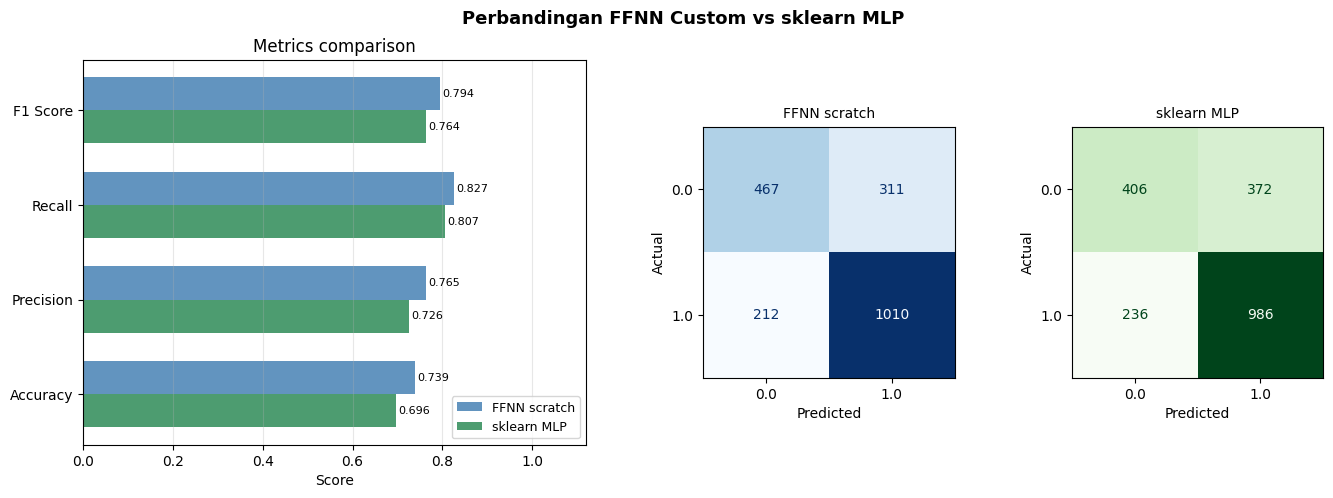

In [20]:
viz.plot_sklearn_comparison(
    y_true         = y_test,
    y_pred_custom  = y_pred_scratch,
    y_pred_sklearn = y_pred_scikit,
    label_custom  = 'FFNN scratch',
    label_sklearn  = 'sklearn MLP',
    # save_path      = '../output/sklearn_comparison.png',
)

## Save Model

In [21]:
# os.makedirs('../results', exist_ok=True)
# model.save('../results/model.npz')

## Verifikasi Load Model